# **Multi-Agent Content Writer**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

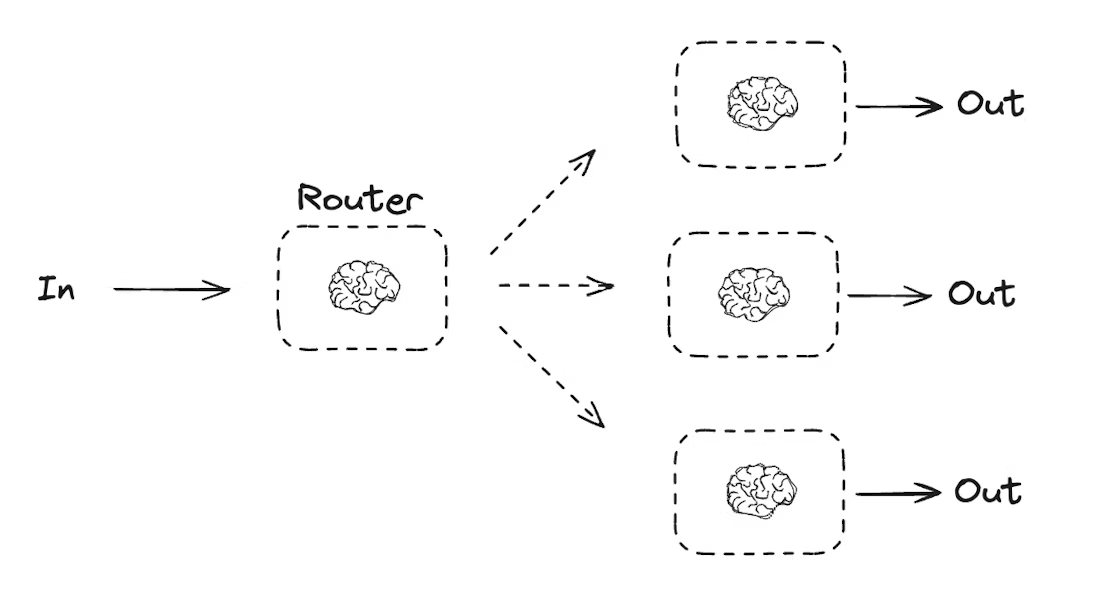




## **💡Tips**

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Steps**




### Step 1: Setup
Install `langgraph`, `langchain`, `langchain-openai`. Configure your LLM.


In [ ]:
!pip install -q langgraph langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_APIKEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

### Step 2: Define State
Create a shared `TypedDict` with: `user_input`, `route`, `output`, `messages`. Use `add_messages` reducer on messages.



In [ ]:
import operator
from langchain.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from typing import List, TypedDict, Annotated, Literal

class ContentWriterState(TypedDict):
    user_input: str
    route: str
    output: str
    messages: Annotated[List[AnyMessage], operator.add]

### Step 3: Router Node
Classifies input into `seo_blog_writer` / `x_blog_writer` / `general`. Returns only one word. Also persists user input into messages.



In [ ]:
from langchain_openai import ChatOpenAI

class RoutingResult(TypedDict):
    route: Literal["seo_blog_writer", "x_blog_writer", "general"]

router_llm = ChatOpenAI(model="gpt-4o",
                        temperature=0.2
                        ).with_structured_output(RoutingResult)

router_system_prompt = """
You are a Content Writter Router that can dispatch to MULTIPLE agents.

AVAILABLE AGENTS:
1. seo_blog_writer - writes long-form blog posts, uses research & keyword tools autonomously
2. x_blog_writer - writes short tweets (<280 chars), uses trending topic tools autonomously
3. general - answers everything else (greetings, questions, etc.) using conversation memory
"""

def router_node(state: ContentWriterState) -> dict:
    query = state["user_input"]
    msgs = [SystemMessage(content=router_system_prompt), HumanMessage(content=query)]
    response = router_llm.invoke(msgs)
    return {"messages": [HumanMessage(content=query)],
            "route": response["route"]
            }

In [ ]:
response = router_node({"user_input":"Write a post for X about Iran-US War"})
response

router is called
router was ended


{'messages': HumanMessage(content='Write a post for X about Iran-US War', additional_kwargs={}, response_metadata={}),
 'route': 'x_blog_writer'}

### Step 4: Tools
Define 2 tools with `@tool`: `research_tool` (finds articles/references) and `internet_search_tool` (finds SEO keywords/trending topics).



In [ ]:
!pip install -q langchain-tavily google-search-results

  Preparing metadata (setup.py) ... done


In [ ]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from serpapi import GoogleSearch
import json

try:
    api_key_from_secrets = userdata.get("SERPAPI_API_KEY")
    os.environ["SERPAPI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your Serp API key: ")

try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [ ]:
@tool(description="Use a Deep Research agent (Tavily Deep Search) to fetch real articles, papers, and references.")
def research_tool(query: str) -> str:
  search = TavilySearch(max_results=10,
                        topic="general",
                        # include_answer=False,
                        # include_raw_content=False,
                        include_images=True,
                        include_image_descriptions=True,
                        search_depth="advanced",
                        # time_range="day",
                        #include_domains=None,
                        # exclude_domains=None
                        ).invoke("query")
  return json.dumps(search)

@tool(description="Use SerpAPI, Google Custom Search API, for quick lookups like SEO keywords, trending topics, and hashtags.")
def internet_search_tool(query: str) -> str:
  params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google',
        'q': query
  }
  search = GoogleSearch(params)
  return json.dumps(search.get_dict())

In [ ]:
response = internet_search_tool.invoke("best SEO keywords for iranian online grocery store")
response

'{"search_metadata": {"id": "69d8131828b27b0f7a3ce72e", "status": "Success", "json_endpoint": "https://serpapi.com/searches/dHL9NyhaZUKJm25TDNAlKw/69d8131828b27b0f7a3ce72e.json", "pixel_position_endpoint": "https://serpapi.com/searches/dHL9NyhaZUKJm25TDNAlKw/69d8131828b27b0f7a3ce72e.json_with_pixel_position", "created_at": "2026-04-09 20:59:04 UTC", "processed_at": "2026-04-09 20:59:04 UTC", "google_url": "https://www.google.com/search?q=best+SEO+keywords+for+iranian+online+grocery+store&oq=best+SEO+keywords+for+iranian+online+grocery+store&sourceid=chrome&ie=UTF-8", "raw_html_file": "https://serpapi.com/searches/dHL9NyhaZUKJm25TDNAlKw/69d8131828b27b0f7a3ce72e.html", "total_time_taken": 0.88}, "search_parameters": {"engine": "google", "q": "best SEO keywords for iranian online grocery store", "google_domain": "google.com", "device": "desktop"}, "search_information": {"query_displayed": "best SEO keywords for iranian online grocery store", "total_results": 379000, "time_taken_displayed"

### Step 5: SEO Blog Writer
Bind both tools to LLM. Agent checks state messages for tool loop continuation. Writes structured blog with headings and CTA.



In [ ]:
from langchain.agents import create_agent

llm = ChatOpenAI(model="gpt-4o",
                 temperature=0.2
                 )

seo_blog_writter_system_prompt = """
You are an expert SEO blog writer with access to tools.

You have two tools:
1. research_tool — Use this to find content, references, and insights to enrich the blog.
2. internet_search_tool — Use this to check SEO keywords, trending terms, and optimize content.

Workflow:
- First, use research_tool to gather relevant content.
- Then, use internet_search_tool to find the best SEO keywords.
- Finally, write a well-structured, keyword-optimized blog post.

Include: compelling title, introduction, H2/H3 subheadings, structured paragraphs, and a CTA.
"""

SEO_BLOG_WRITER = create_agent(
    model=llm,  # Default model
    tools=[research_tool, internet_search_tool],
    system_prompt=seo_blog_writter_system_prompt
)

def seo_node(state: ContentWriterState) -> dict:
    # query = state["user_input"]
    response = SEO_BLOG_WRITER.invoke({"messages": state["messages"]})
    return {
        "messages":[response["messages"][-1]],
        "output":response["messages"][-1].content
        }

In [ ]:
response = SEO_BLOG_WRITER.invoke({"input": "Write a blog post about Iran-US War"})
response

{'messages': [AIMessage(content='To create a well-optimized blog post, let\'s first gather relevant content and insights on the topic of "The Benefits of Remote Work for Companies and Employees." Then, we\'ll find the best SEO keywords to ensure the blog is optimized for search engines. \n\nLet\'s start by using the research tool to gather content and the internet search tool to find SEO keywords simultaneously.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 216, 'total_tokens': 347, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f9e6b50693', 'id': 'chatcmpl-DSsCc4nIWESoG3acim4bsR1HPfDNy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_r

### Step 6: X/Twitter Writer
Bind only `internet_search_tool`. Same loop pattern. Writes short posts with emojis and hashtags.



In [ ]:
x_blog_writer_system_prompt = """
You are an expert X (Twitter) content writer with access to tools.

You have one tool:
1. internet_search_tool — Use this to find trending topics, viral headlines, and popular hashtags related to the user's request.

Workflow:
- First, use internet_search_tool to find trending topics and hashtags.
- Then, write an engaging, viral-worthy X post using those insights.

Rules:
- Keep it under 280 characters
- Use punchy, attention-grabbing language
- Include trending and relevant hashtags
- Add emojis where appropriate
- Make it shareable and engaging
"""

X_BLOG_WRITER = create_agent(
    model=llm,
    tools=[internet_search_tool],
    system_prompt=x_blog_writer_system_prompt
)

def x_node(state: ContentWriterState) -> dict:
    # query = state["user_input"]
    response = X_BLOG_WRITER.invoke({"messages": state["messages"]})
    return {
        "messages":[response["messages"][-1]],
        "output":response["messages"][-1].content
        }

### Step 7: General Handler
Uses full message history from state to answer general queries with context. Saves both user and AI messages for persistence.



In [ ]:
general_system_prompt = """
You are a helpful assistant. You have access to the full conversation history.
Answer the user's question briefly and clearly using context from previous messages if relevant.
Let them know you specialize in SEO blog writing and X/Twitter post writing if they need content.
"""

def general_node(state: ContentWriterState) -> dict:
    # query = state["user_input"]
    response = llm.invoke([SystemMessage(content=general_system_prompt)] + state["messages"])

    return {
        "messages":[AIMessage(content=response.content)],
        "output":response.content
        }

### Step 8: Build Graph
Add all nodes. Router → 3-way conditional edges. Agent ↔ tool loops using `should_continue` functions. General → END.



In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ContentWriterState)

builder.add_node("router_node", router_node)
builder.add_node("seo_blog_writer", seo_node)
builder.add_node("x_blog_writer", x_node)
builder.add_node("general", general_node)

builder.add_edge(START, "router_node")
builder.add_conditional_edges("router_node",
                              lambda state: state["route"],
                              ["seo_blog_writer", "x_blog_writer", "general"]
                              )
builder.add_edge("seo_blog_writer", END)
builder.add_edge("x_blog_writer", END)
builder.add_edge("general", END)

### Step 9: Persistence
Add `MemorySaver` checkpointer. Compile graph. Pass `thread_id` in config on every call.


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

checkpointer = InMemorySaver()

agent = builder.compile(checkpointer=checkpointer)

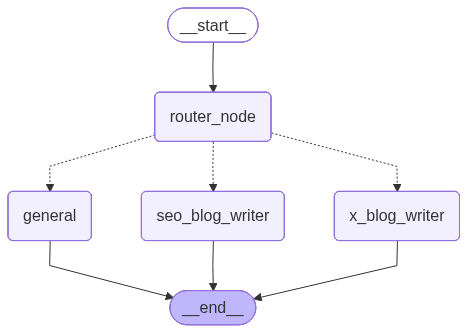

In [ ]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### Step 10: Test

In [ ]:
config = {"configurable": {"thread_id": "user-01"}}
result = agent.invoke(
    {
        "user_input": "Also write a blog post"
    },
    config=config
)

print(result['output'])

### The Iran-US Conflict: A Deep Dive into Tensions and Implications

#### Introduction
The Iran-US conflict has been a focal point of international relations for decades, marked by a series of political, military, and economic confrontations. As tensions escalate in 2023, understanding the historical context and current dynamics is crucial for comprehending the potential global implications.

#### Historical Context
The roots of the Iran-US conflict can be traced back to the 1953 CIA-backed coup in Iran, which overthrew Prime Minister Mohammad Mossadegh. This event set the stage for decades of mistrust and animosity. The 1979 Iranian Revolution further strained relations, leading to the hostage crisis and the eventual severance of diplomatic ties.

#### Recent Developments
In recent years, the conflict has been characterized by a series of escalations, including the US withdrawal from the Iran nuclear deal in 2018 and the subsequent re-imposition of sanctions. In 2023, tensions have i

In [ ]:
result

{'user_input': 'Also write a blog post',
 'route': 'seo_blog_writer',
 'output': "### The Iran-US Conflict: A Deep Dive into Tensions and Implications\n\n#### Introduction\nThe Iran-US conflict has been a focal point of international relations for decades, marked by a series of political, military, and economic confrontations. As tensions escalate in 2023, understanding the historical context and current dynamics is crucial for comprehending the potential global implications.\n\n#### Historical Context\nThe roots of the Iran-US conflict can be traced back to the 1953 CIA-backed coup in Iran, which overthrew Prime Minister Mohammad Mossadegh. This event set the stage for decades of mistrust and animosity. The 1979 Iranian Revolution further strained relations, leading to the hostage crisis and the eventual severance of diplomatic ties.\n\n#### Recent Developments\nIn recent years, the conflict has been characterized by a series of escalations, including the US withdrawal from the Iran n